# 🥊 Search Comparison: Dense vs ColBERT
## Live demo showing ColBERT's advantages with clear examples!

This notebook provides a focused comparison between **Dense Retrieval** and **ColBERT** using our restaurant review dataset with proper ground truth labels.

### 🎯 What We'll Demonstrate:
1. **Setup**: Load both systems quickly
2. **Ground Truth Cases**: 2 carefully chosen examples where ColBERT should dominate
3. **Live Side-by-Side**: See the results in real-time
4. **Explainability**: Visualize why ColBERT works better

### 🏆 Expected Outcomes:
- **ColBERT Dominance**: Better handling of complex queries
- **Clear Insights**: Immediate understanding of the differences
- **Explainability Bonus**: See which tokens matched

Let's see ColBERT in action! 🚀

In [1]:
# Setup - Load both systems
import sys
sys.path.append('../..')
from setup import *

print("🔄 Loading systems...")

# Load reasoning dataset
data_path = os.getenv('DATA_DIR') + '/restaurant_reviews.csv'
df = pd.read_csv(data_path)
print(f"📊 Loaded {len(df)} restaurant reviews with reasoning categories")

print("✅ Setup complete!")

✅ Loaded environment from: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/notebooks/ColBERT/../../.env
📂 Working directory: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation
🎯 Project root: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation
📊 Data directory: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/data
🔧 Device: mps
📁 Environment variables loaded: 83
🔄 Loading systems...
📊 Loaded 12 restaurant reviews with reasoning categories
✅ Setup complete!


In [18]:
get_device()

'mps'

In [ ]:
 # Load ColBERT System
from pylate import models
import torch
import json
import lancedb

# Load configuration from notebook 3
# Connect to vector database
col_db = lancedb.connect(os.getenv('VECTOR_STORE_DIR'))
config_path = os.path.join(os.getenv('MODEL_DIR'),
'colbert_config.json')
with open(config_path, 'r') as f:
    colbert_config = json.load(f)

# Load ColBERT model with saved config including query_length
colbert_model = models.ColBERT(
      model_name_or_path='sentence-transformers/all-MiniLM-L6-v2',
      device=,
      query_length=16
  )

# Just open the existing table from notebook 3
colbert_table = col_db.open_table('colbert_reviews')
print(f"✅ ColBERT table loaded: {len(colbert_table)} records")

The checkpoint does not contain a linear projection layer. Adding one with output dimensions (384, 128).
Created a PyLate model from base encoder.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The tokenizer does not support resizing the token embeddings, the prefixes token have not been added to vocabulary.


✅ ColBERT table loaded: 12 records


In [3]:
colbert_config

{'model_name': 'sentence-transformers/all-MiniLM-L6-v2',
 'embedding_dimension': 128,
 'device': 'mps',
 'table_name': 'colbert_reviews',
 'query_length': 16,
 'num_reviews': 12,
 'total_tokens': 1190,
 'avg_tokens_per_review': 99.16666666666667,
 'storage_kb': 1216.0,
 'created_at': '2025-08-22T16:38:06.381359'}

In [17]:

# Load Dense Retrieval System
from sentence_transformers import SentenceTransformer

# Load models
device_for_dense = 'cpu' if get_device() == 'mps' else get_device()
dense_model = SentenceTransformer(os.getenv('DENSE_MODEL_NAME'),
device=device_for_dense)



# Just open the existing dense table from notebook 2
dense_table = db.open_table("dense_reviews")
print(f"✅ Dense table loaded: {len(dense_table)} records")

✅ Dense table loaded: 12 records


In [5]:
# 🔧 Search Functions
import time
from typing import List, Tuple, Dict
# 6. Basic Dense Search
def search_dense_reviews(query, dense_model, dense_table, top_k=3):
    """
    Search restaurant reviews using dense embeddings (traditional RAG)
    
    Args:
        query (str): Search query
        top_k (int): Number of results to return
    
    Returns:
        pandas.DataFrame: Top matching reviews with similarity scores
    """
    print(f"🔍 Dense search query: '{query}'")
    
    # Encode query with the same model
    query_start = time.time()
    query_embedding = dense_model.encode(query)
    query_time = time.time() - query_start
    
    print(f"   ⚡ Query encoding time: {query_time:.3f} seconds")
    
    # Search using LanceDB
    search_start = time.time()
    results = dense_table.search(query_embedding).limit(top_k).to_pandas()
    search_time = time.time() - search_start
    
    print(f"   🚀 Search time: {search_time:.3f} seconds")
    print(f"   📊 Found {len(results)} results")
    
    return results

print("✅ Dense search function ready!")
print("📦 How it works:")
print("   1. Query → Dense model → Single 384-dim vector")
print("   2. Compare query vector vs all document vectors")
print("   3. Return top-K most similar documents")
print("   4. Uses cosine similarity in 384-dimensional space")

✅ Dense search function ready!
📦 How it works:
   1. Query → Dense model → Single 384-dim vector
   2. Compare query vector vs all document vectors
   3. Return top-K most similar documents
   4. Uses cosine similarity in 384-dimensional space


In [6]:
def colbert_search(query: str, table, model, top_k: int = 3) -> List[Dict]:
    """
    Perform ColBERT search using MaxSim operation.
    
    Args:
        query: Search query string
        table: LanceDB table with ColBERT embeddings
        model: ColBERT model for encoding query
        top_k: Number of top results to return
    
    Returns:
        List of search results with scores
    """
    print(f"🔍 ColBERT search: '{query}'")
    
    # Encode query with ColBERT (use same preprocessing as documents)
    query_embeddings = model.encode([query], is_query=True)[0]  # Shape: [query_tokens, dim]
    
    # Convert to tensor if it's a numpy array
    if isinstance(query_embeddings, np.ndarray):
        query_embeddings = torch.tensor(query_embeddings, dtype=torch.float32)
    
    print(f"📝 Query tokens: {query_embeddings.shape[0]}")
    
    # Get all documents from table
    all_docs = table.to_pandas()
    
    results = []
    
    # Compute MaxSim for each document
    for idx, row in all_docs.iterrows():
        # Handle different formats from LanceDB
        doc_embeddings_data = row['token_embeddings']
        
        # Convert to proper tensor format
        if isinstance(doc_embeddings_data, list):
            # Direct list to tensor
            doc_embeddings = torch.tensor(doc_embeddings_data, dtype=torch.float32)
        elif isinstance(doc_embeddings_data, np.ndarray):
            # Convert numpy array (possibly of objects) to list first, then to tensor
            doc_embeddings = torch.tensor(doc_embeddings_data.tolist(), dtype=torch.float32)
        else:
            # Fallback: try to convert via list
            doc_embeddings = torch.tensor(list(doc_embeddings_data), dtype=torch.float32)
        
        # Compute similarity matrix: [query_tokens, doc_tokens]
        similarity_matrix = torch.matmul(query_embeddings, doc_embeddings.T)
        
        # MaxSim: For each query token, find max similarity with any doc token
        max_similarities = torch.max(similarity_matrix, dim=1)[0]  # Shape: [query_tokens]
        
        # Final score: Sum of max similarities
        score = torch.sum(max_similarities).item()
        
        results.append({
            'id': row['id'],
            'restaurant': row['restaurant'],
            'review': row['review'],
            'reviewer': row['reviewer'],
            'rating': row['rating'],
            'score': score,
            'num_tokens': row['num_tokens'],
            'combined_text': row['combined_text']
        })
    
    # Sort by score (descending)
    results.sort(key=lambda x: x['score'], reverse=True)
    
    print(f"✅ Found {len(results)} results, returning top {top_k}")
    return results[:top_k]

def display_colbert_results(results: List[Dict], query: str):
    """
    Display ColBERT search results in a readable format.
    """
    print(f"\n🎯 ColBERT Results for: '{query}'")
    print("=" * 80)
    
    for i, result in enumerate(results, 1):
        print(f"\n{i}. {result['restaurant']} (⭐ {result['rating']}/5)")
        print(f"   Score: {result['score']:.3f} | Tokens: {result['num_tokens']} | Reviewer: {result['reviewer']}")
        print(f"   Review: {result['review'][:200]}{'...' if len(result['review']) > 200 else ''}")
        print("-" * 40)

print("✅ ColBERT search functions defined!")

✅ ColBERT search functions defined!


In [7]:
import json
def load_json_questions(path:str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

## Simple Questions

In [8]:
data_dir = os.getenv("DATA_DIR")
# Print the value of the data directory environment variable to verify where data files are expected to be loaded from.
# This helps ensure that the DATA_DIR variable is set correctly and points to the right location.
print("DATA_DIR environment variable is set to:", data_dir)
import os
simple_questions_path = os.path.join(data_dir, "simple_questions.json")
print(f"Loading simple questions from: {simple_questions_path}")
simple_questions = load_json_questions(simple_questions_path)

DATA_DIR environment variable is set to: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/data
Loading simple questions from: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/data/simple_questions.json


In [9]:
simple_questions

{'simple_queries': [{'query_id': 1,
   'query': 'Italian restaurant',
   'expected_results': [{'restaurant_id': 1,
     'restaurant': "Mario's Bistro",
     'relevance': 'highly_relevant',
     'reason': 'Explicitly Italian cuisine, authentic pasta'},
    {'restaurant_id': 5,
     'restaurant': "Tony's Italian Kitchen",
     'relevance': 'highly_relevant',
     'reason': 'Italian restaurant with authentic food and wine list'}]},
  {'query_id': 2,
   'query': 'sushi place',
   'expected_results': [{'restaurant_id': 2,
     'restaurant': 'Sakura Sushi',
     'relevance': 'highly_relevant',
     'reason': 'Sushi restaurant with vegetarian options'},
    {'restaurant_id': 8,
     'restaurant': 'Neko Sushi',
     'relevance': 'highly_relevant',
     'reason': 'Exclusive sushi experience, omakase style'}]},
  {'query_id': 3,
   'query': 'coffee shop',
   'expected_results': [{'restaurant_id': 3,
     'restaurant': 'Code & Coffee',
     'relevance': 'highly_relevant',
     'reason': 'Coffee s

In [10]:
first_simple_query = simple_questions['simple_queries'][0]
from pprint import pprint

print("First Simple Query Example:")
pprint(first_simple_query)

First Simple Query Example:
{'expected_results': [{'reason': 'Explicitly Italian cuisine, authentic pasta',
                       'relevance': 'highly_relevant',
                       'restaurant': "Mario's Bistro",
                       'restaurant_id': 1},
                      {'reason': 'Italian restaurant with authentic food and '
                                 'wine list',
                       'relevance': 'highly_relevant',
                       'restaurant': "Tony's Italian Kitchen",
                       'restaurant_id': 5}],
 'query': 'Italian restaurant',
 'query_id': 1}


In [11]:
print(first_simple_query['query'])

Italian restaurant


In [12]:

first_dense_result = search_dense_reviews(first_simple_query['query'], dense_model, dense_table)
first_colbert_result = colbert_search(first_simple_query['query'], colbert_table, colbert_model)

🔍 Dense search query: 'Italian restaurant'
   ⚡ Query encoding time: 0.101 seconds
   🚀 Search time: 0.052 seconds
   📊 Found 3 results
🔍 ColBERT search: 'Italian restaurant'
📝 Query tokens: 16
✅ Found 12 results, returning top 3


In [13]:
first_dense_result

,id,restaurant,review,reviewer,rating,text,dense_embedding,_distance
0,1,Mario's Bistro,OMG this little Italian place is a hidden gem!...,Sarah M.,5,Mario's Bistro: OMG this little Italian place ...,"[-0.03517798, 0.049469754, 0.033678696, 0.0862...",0.700318
1,5,Tony's Italian Kitchen,Wanted to take my wife somewhere nice for our ...,James R.,3,Tony's Italian Kitchen: Wanted to take my wife...,"[-0.014235651, 0.04111316, 0.025100995, 0.1170...",0.731620
2,7,Giuseppe's Pizza,Brought the whole family here for my son's bir...,Mom of 3,4,Giuseppe's Pizza: Brought the whole family her...,"[-0.021022871, 0.097545065, 0.01507072, 0.0607...",0.773217


In [14]:
first_colbert_result

[{'id': 8,
  'restaurant': 'Neko Sushi',
  'review': "This is hands down the most exclusive sushi experience in the city. $150 per person minimum, only 8 seats at the counter, and you have to book weeks in advance. But if you're a serious sushi lover, it's incredible. The chef chooses everything (omakase style) and each piece is perfection. Warning though - they have absolutely ZERO vegetarian options. Like, don't even ask. It's traditional fish and seafood only. My vegetarian friend had to sit there and watch us eat, felt terrible. If you eat fish and have money to burn, it's amazing. Otherwise skip it.",
  'reviewer': 'Sushi_Master99',
  'rating': 4,
  'score': 4.123420715332031,
  'num_tokens': 111,
  'combined_text': "Neko Sushi: This is hands down the most exclusive sushi experience in the city. $150 per person minimum, only 8 seats at the counter, and you have to book weeks in advance. But if you're a serious sushi lover, it's incredible. The chef chooses everything (omakase styl

In [15]:
colbert_table.to_pandas().loc[4]

id                                                                  5
restaurant                                     Tony's Italian Kitchen
review              Wanted to take my wife somewhere nice for our ...
reviewer                                                     James R.
rating                                                              3
combined_text       Tony's Italian Kitchen: Wanted to take my wife...
token_embeddings    [[-0.1608821153640747, -0.0018682751106098294,...
num_tokens                                                        101
Name: 4, dtype: object

In [16]:
# Test the EXACT same query encoding
test_query = "Italian restaurant"

# 1. Encode query
q_emb = colbert_model.encode([test_query], is_query=True)[0]
print(f"Query shape: {q_emb.shape}")
print(f"Query sum: {q_emb.sum()}")  # This should be identical

# 2. Get Tony's Italian embeddings
tony_row = colbert_table.to_pandas().loc[4]  # Assuming Tony's is row 4
print(f"Tony's restaurant: {tony_row['restaurant']}")

# 3. Manual MaxSim calculation
if isinstance(tony_row['token_embeddings'], list):
    # Direct list to tensor
    doc_embeddings = torch.tensor(tony_row['token_embeddings'], dtype=torch.float32)
elif isinstance(tony_row['token_embeddings'], np.ndarray):
    # Convert numpy array (possibly of objects) to list first, then to tensor
    doc_embeddings = torch.tensor(tony_row['token_embeddings'].tolist(), dtype=torch.float32)
else:
    # Fallback: try to convert via list
    doc_embeddings = torch.tensor(list(tony_row['token_embeddings']), dtype=torch.float32)
q_tensor = torch.tensor(q_emb, dtype=torch.float32) if isinstance(q_emb,
np.ndarray) else q_emb

sim_matrix = torch.matmul(q_tensor, doc_embeddings.T)
max_sims = torch.max(sim_matrix, dim=1)[0]
score = torch.sum(max_sims).item()

print(f"Tony's manual score: {score}")
print(f"Sim matrix shape: {sim_matrix.shape}")
print(f"Max sims: {max_sims[:5]}")  # First 5 max similarities

Query shape: (16, 128)
Query sum: 5.586906909942627
Tony's restaurant: Tony's Italian Kitchen
Tony's manual score: 2.7899653911590576
Sim matrix shape: torch.Size([16, 101])
Max sims: tensor([0.1373, 0.2242, 0.1541, 0.1152, 0.1277])


In [16]:
display_colbert_results(first_colbert_result, first_simple_query['query'])


🎯 ColBERT Results for: 'Italian restaurant'

1. Family Garden (⭐ 5/5)
   Score: 3.828 | Tokens: 104 | Reviewer: Busy_Mom
   Review: This place is a godsend for parents! The booths are huge and comfortable, perfect for our family of 5. They have a great kids menu but also tons of healthy options for the adults - I got this amazing ...
----------------------------------------

2. Le Bernardin SF (⭐ 5/5)
   Score: 3.641 | Tokens: 107 | Reviewer: FoodieJen
   Review: Look, I'm not gonna lie - this place is EXPENSIVE. Like, really expensive. We paid $220 per person for the tasting menu. But holy shit, it was worth every single penny. I've never experienced food lik...
----------------------------------------

3. Green Tea House (⭐ 4/5)
   Score: 3.618 | Tokens: 102 | Reviewer: ZenSeeker
   Review: If you're looking for a peaceful escape from the city chaos, this is your spot. It's incredibly quiet and zen-like, perfect for reading or having deep conversations. They have an amazing selectio

In [47]:
dir(colbert_model)

['T_destination',
 '__add__',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmul__',
 '__setattr__',
 '__setitem__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_create_model_card',
 '_encode_multi_process_worker',
 '_eval_during_training',
 '_first_module',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_h

In [51]:
# Check model config
print("Model name:", colbert_model._get_name)
print("Model config:")
print(colbert_model._model_config)

Model name: <bound method Module._get_name of ColBERT(
  (0): Transformer({'max_seq_length': 31, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Dense({'in_features': 384, 'out_features': 128, 'bias': False, 'activation_function': 'torch.nn.modules.linear.Identity'})
)>
Model config:
{'__version__': {'sentence_transformers': '2.0.0', 'transformers': '4.6.1', 'pytorch': '1.8.1'}}


In [ ]:
# 📊 Simple Heatmap Visualization

# Create a simple heatmap showing token-to-token similarities
plt.figure(figsize=(12, 6))

# Take a subset for visualization clarity
query_words_viz = query_words[:8]  # First 8 query words
doc_words_viz = doc_words[:15]     # First 15 document words

# Extract relevant portion of similarity matrix
viz_matrix = similarity_matrix[:len(query_words_viz), :len(doc_words_viz)].numpy()

plt.imshow(viz_matrix, cmap='RdYlBu_r', aspect='auto')
plt.colorbar(label='Similarity Score')

plt.xlabel('Document Tokens', fontsize=12)
plt.ylabel('Query Tokens', fontsize=12)
plt.title('ColBERT Token-to-Token Similarity Matrix\n(Darker = Higher Similarity)', fontsize=14)

# Add token labels
plt.xticks(range(len(doc_words_viz)), doc_words_viz, rotation=45, ha='right')
plt.yticks(range(len(query_words_viz)), query_words_viz)

# Add MaxSim indicators
for i in range(len(query_words_viz)):
    max_j = np.argmax(viz_matrix[i])
    plt.scatter(max_j, i, s=100, c='white', marker='*', edgecolors='black', linewidth=1)

plt.tight_layout()
plt.show()

print("⭐ White stars show the BEST match for each query token (MaxSim operation)")
print("🎯 This is ColBERT's 'secret sauce' - finding optimal matches at token level!")

In [ ]:
# 🎓 Key Takeaways

print("🏆 COMPARISON SUMMARY")
print("=" * 50)
print()

print("📦 DENSE RETRIEVAL:")
print("   ✅ Fast search (single vector comparison)")
print("   ✅ Low storage requirements") 
print("   ✅ Simple implementation")
print("   ❌ Limited with multi-constraint queries")
print("   ❌ No explainability")
print()

print("🔍 ColBERT (Late Interaction):")
print("   ✅ Excellent for complex queries")
print("   ✅ Handles multiple constraints well")  
print("   ✅ Explainable (token-level matching)")
print("   ✅ Better understanding of negation logic")
print("   ❌ Slower search")
print("   ❌ Higher storage requirements")
print()

print("🎯 WHEN TO USE:")
print("   📦 Dense: Simple searches, speed critical, resource constrained")
print("   🔍 ColBERT: Complex queries, quality over speed, need explainability")
print()

print("💡 MAIN INSIGHT:")
print("   ColBERT's token-level matching preserves nuance that dense retrieval loses.")
print("   This makes it superior for complex, real-world search scenarios.")
print()

print("🚀 NEXT STEPS:")
print("   Try hybrid approaches: Dense for initial filtering + ColBERT for reranking!")

print("\n" + "="*60)
print("🎉 Demo complete! ColBERT shows clear advantages for complex queries.")

In [15]:
def compare_search_results(query: str, top_k: int = 3) -> ComparisonMetrics:
    """Compare search results between dense and ColBERT"""
    print(f"🔍 Comparing results for: '{query}'")
    print("=" * 60)
    
    # Get results from both methods
    dense_results, dense_time = dense_search(query, top_k)
    colbert_results, colbert_time = colbert_search(query, top_k)
    
    # Calculate overlap
    dense_ids = set(r.id for r in dense_results)
    colbert_ids = set(r.id for r in colbert_results)
    overlap = len(dense_ids & colbert_ids)
    overlap_percentage = (overlap / top_k) * 100
    
    # Compare average ratings
    dense_avg_rating = np.mean([r.rating for r in dense_results]) if dense_results else 0
    colbert_avg_rating = np.mean([r.rating for r in colbert_results]) if colbert_results else 0
    avg_rating_diff = colbert_avg_rating - dense_avg_rating
    
    # Display results side by side
    print(f"🚀 Performance: Dense {dense_time:.3f}s vs ColBERT {colbert_time:.3f}s")
    print(f"🎯 Overlap: {overlap}/{top_k} results ({overlap_percentage:.0f}%)")
    print(f"⭐ Avg ratings: Dense {dense_avg_rating:.1f} vs ColBERT {colbert_avg_rating:.1f}")
    print()
    
    # Show results side by side
    for i in range(max(len(dense_results), len(colbert_results))):
        print(f"Rank {i+1}:")
        
        # Dense result
        if i < len(dense_results):
            dr = dense_results[i]
            print(f"   📦 Dense:   {dr.restaurant} (⭐{dr.rating}) Score: {dr.score:.3f}")
            print(f"              {dr.review[:80]}...")
        else:
            print(f"   📦 Dense:   (no result)")
        
        # ColBERT result
        if i < len(colbert_results):
            cr = colbert_results[i]
            print(f"   🔍 ColBERT: {cr.restaurant} (⭐{cr.rating}) Score: {cr.score:.3f}")
            print(f"              {cr.review[:80]}...")
        else:
            print(f"   🔍 ColBERT: (no result)")
        
        # Highlight if same restaurant
        if (i < len(dense_results) and i < len(colbert_results) and 
            dense_results[i].id == colbert_results[i].id):
            print(f"              ✅ SAME RESTAURANT")
        elif (i < len(dense_results) and i < len(colbert_results)):
            print(f"              🔄 DIFFERENT RESTAURANTS")
        print()
    
    return ComparisonMetrics(
        query=query,
        dense_results=dense_results,
        colbert_results=colbert_results,
        dense_search_time=dense_time,
        colbert_search_time=colbert_time,
        overlap_percentage=overlap_percentage,
        avg_rating_diff=avg_rating_diff
    )

print("✅ Search comparison function ready!")

✅ Search comparison function ready!


In [16]:
# Test 1: Simple keyword search
round1_query = "Italian authentic pasta"
round1_results = compare_search_results(round1_query)

print(f"🏆 Round 1 Analysis:")
if round1_results.overlap_percentage > 66:
    print(f"   Result: TIE - High overlap ({round1_results.overlap_percentage:.0f}%)")
elif round1_results.avg_rating_diff > 0.5:
    print(f"   Result: ColBERT WINS - Higher avg rating (+{round1_results.avg_rating_diff:.1f})")
elif round1_results.avg_rating_diff < -0.5:
    print(f"   Result: Dense WINS - Higher avg rating (+{-round1_results.avg_rating_diff:.1f})")
else:
    print(f"   Result: TIE - Similar ratings")

🔍 Comparing results for: 'Italian authentic pasta'
🚀 Performance: Dense 0.024s vs ColBERT 0.037s
🎯 Overlap: 0/3 results (0%)
⭐ Avg ratings: Dense 4.0 vs ColBERT 2.7

Rank 1:
   📦 Dense:   Mario's Bistro (⭐5) Score: 0.259
              OMG this little Italian place is a hidden gem! 😍 Went there last night with my b...
   🔍 ColBERT: Starbucks Downtown (⭐2) Score: 8.230
              Don't even think about trying to work from this Starbucks location. Yes they hav...
              🔄 DIFFERENT RESTAURANTS

Rank 2:
   📦 Dense:   Tony's Italian Kitchen (⭐3) Score: 0.033
              Wanted to take my wife somewhere nice for our anniversary and Tony's looked perf...
   🔍 ColBERT: Code & Coffee (⭐5) Score: 7.953
              As a freelance developer, I'm always hunting for good work spots and Code & Coff...
              🔄 DIFFERENT RESTAURANTS

Rank 3:
   📦 Dense:   Giuseppe's Pizza (⭐4) Score: -0.014
              Brought the whole family here for my son's birthday - 8 people total. This pl

### 🥊 Round 2: Multi-Constraint Query

In [17]:
# Test 2: Multi-constraint query (ColBERT should excel)
round2_query = "good for working laptop wifi quiet"
round2_results = compare_search_results(round2_query)

print(f"🏆 Round 2 Analysis:")
print(f"   This query has multiple constraints: 'working', 'laptop', 'wifi', 'quiet'")
print(f"   ColBERT can match each constraint separately")
print(f"   Dense must compress all constraints into one similarity score")

if round2_results.overlap_percentage < 34:
    print(f"   Result: DIFFERENT APPROACHES - Low overlap ({round2_results.overlap_percentage:.0f}%)")
    print(f"   This showcases the fundamental difference between the methods")
else:
    print(f"   Result: Similar results - Both methods handled multi-constraints well")

🔍 Comparing results for: 'good for working laptop wifi quiet'
🚀 Performance: Dense 0.027s vs ColBERT 0.039s
🎯 Overlap: 3/3 results (100%)
⭐ Avg ratings: Dense 2.7 vs ColBERT 2.7

Rank 1:
   📦 Dense:   Code & Coffee (⭐5) Score: -0.052
              As a freelance developer, I'm always hunting for good work spots and Code & Coff...
   🔍 ColBERT: Code & Coffee (⭐5) Score: 8.018
              As a freelance developer, I'm always hunting for good work spots and Code & Coff...
              ✅ SAME RESTAURANT

Rank 2:
   📦 Dense:   Brew & Bytes (⭐1) Score: -0.150
              What a disappointment! Saw their signs about being 'laptop friendly' so I came t...
   🔍 ColBERT: Starbucks Downtown (⭐2) Score: 7.597
              Don't even think about trying to work from this Starbucks location. Yes they hav...
              🔄 DIFFERENT RESTAURANTS

Rank 3:
   📦 Dense:   Starbucks Downtown (⭐2) Score: -0.378
              Don't even think about trying to work from this Starbucks location. Yes they 

### 🥊 Round 3: Complex Contextual Query

In [18]:
# Test 3: Complex contextual query
round3_query = "expensive fine dining special occasion worth money"
round3_results = compare_search_results(round3_query)

print(f"🏆 Round 3 Analysis:")
print(f"   Complex query with context: 'expensive' + 'worth money' paradox")
print(f"   ColBERT can understand: expensive BUT worth it")
print(f"   Dense might struggle with contradictory terms")

# Analyze the specific results
for method, results in [('Dense', round3_results.dense_results), ('ColBERT', round3_results.colbert_results)]:
    if results:
        high_rating_count = sum(1 for r in results if r.rating >= 4)
        print(f"   {method}: {high_rating_count}/{len(results)} results are 4+ stars")

🔍 Comparing results for: 'expensive fine dining special occasion worth money'
🚀 Performance: Dense 0.095s vs ColBERT 0.052s
🎯 Overlap: 0/3 results (0%)
⭐ Avg ratings: Dense 3.7 vs ColBERT 2.7

Rank 1:
   📦 Dense:   Le Bernardin SF (⭐5) Score: 0.215
              Look, I'm not gonna lie - this place is EXPENSIVE. Like, really expensive. We pa...
   🔍 ColBERT: Starbucks Downtown (⭐2) Score: 8.526
              Don't even think about trying to work from this Starbucks location. Yes they hav...
              🔄 DIFFERENT RESTAURANTS

Rank 2:
   📦 Dense:   Tony's Italian Kitchen (⭐3) Score: 0.049
              Wanted to take my wife somewhere nice for our anniversary and Tony's looked perf...
   🔍 ColBERT: Code & Coffee (⭐5) Score: 8.167
              As a freelance developer, I'm always hunting for good work spots and Code & Coff...
              🔄 DIFFERENT RESTAURANTS

Rank 3:
   📦 Dense:   Chez Laurent (⭐3) Score: 0.046
              Came here for our 10th wedding anniversary hoping for 

### 🥊 Round 4: Negative Sentiment Query

In [19]:
# Test 4: Negative sentiment query
round4_query = "disappointing overpriced terrible service slow"
round4_results = compare_search_results(round4_query)

print(f"🏆 Round 4 Analysis:")
print(f"   Negative sentiment query - looking for bad reviews")
print(f"   Should return low-rated restaurants")

# Check if results match the sentiment
for method, results in [('Dense', round4_results.dense_results), ('ColBERT', round4_results.colbert_results)]:
    if results:
        low_rating_count = sum(1 for r in results if r.rating <= 2)
        avg_rating = np.mean([r.rating for r in results])
        print(f"   {method}: {low_rating_count}/{len(results)} low ratings, avg: {avg_rating:.1f}")
        
        # Check if reviews contain negative words
        negative_words = ['disappointing', 'overpriced', 'terrible', 'slow', 'bad', 'awful', 'worst']
        for i, result in enumerate(results):
            neg_word_count = sum(1 for word in negative_words if word.lower() in result.review.lower())
            if neg_word_count > 0:
                print(f"     Rank {i+1}: Contains {neg_word_count} negative words")

🔍 Comparing results for: 'disappointing overpriced terrible service slow'
🚀 Performance: Dense 0.023s vs ColBERT 0.045s
🎯 Overlap: 2/3 results (67%)
⭐ Avg ratings: Dense 3.7 vs ColBERT 2.7

Rank 1:
   📦 Dense:   Le Bernardin SF (⭐5) Score: -0.381
              Look, I'm not gonna lie - this place is EXPENSIVE. Like, really expensive. We pa...
   🔍 ColBERT: Code & Coffee (⭐5) Score: 7.664
              As a freelance developer, I'm always hunting for good work spots and Code & Coff...
              🔄 DIFFERENT RESTAURANTS

Rank 2:
   📦 Dense:   Brew & Bytes (⭐1) Score: -0.417
              What a disappointment! Saw their signs about being 'laptop friendly' so I came t...
   🔍 ColBERT: Brew & Bytes (⭐1) Score: 7.219
              What a disappointment! Saw their signs about being 'laptop friendly' so I came t...
              ✅ SAME RESTAURANT

Rank 3:
   📦 Dense:   Code & Coffee (⭐5) Score: -0.522
              As a freelance developer, I'm always hunting for good work spots and Code &

## 📊 Comprehensive Analysis Dashboard

In [20]:
# Run all test queries and collect comprehensive metrics
all_comparisons = []
print("🔍 Running comprehensive comparison across all test queries...")
print()

for i, test_config in enumerate(test_queries[:6], 1):  # Test first 6 queries
    print(f"Test {i}/{len(test_queries[:6])}: {test_config['description']}")
    comparison = compare_search_results(test_config['query'], top_k=3)
    all_comparisons.append(comparison)
    print("\n" + "="*80 + "\n")

print("✅ All comparisons complete!")

🔍 Running comprehensive comparison across all test queries...

Test 1/6: Simple keyword search - should be comparable
🔍 Comparing results for: 'Italian authentic pasta'
🚀 Performance: Dense 0.023s vs ColBERT 0.042s
🎯 Overlap: 0/3 results (0%)
⭐ Avg ratings: Dense 4.0 vs ColBERT 2.7

Rank 1:
   📦 Dense:   Mario's Bistro (⭐5) Score: 0.259
              OMG this little Italian place is a hidden gem! 😍 Went there last night with my b...
   🔍 ColBERT: Starbucks Downtown (⭐2) Score: 8.230
              Don't even think about trying to work from this Starbucks location. Yes they hav...
              🔄 DIFFERENT RESTAURANTS

Rank 2:
   📦 Dense:   Tony's Italian Kitchen (⭐3) Score: 0.033
              Wanted to take my wife somewhere nice for our anniversary and Tony's looked perf...
   🔍 ColBERT: Code & Coffee (⭐5) Score: 7.953
              As a freelance developer, I'm always hunting for good work spots and Code & Coff...
              🔄 DIFFERENT RESTAURANTS

Rank 3:
   📦 Dense:   Giuseppe'

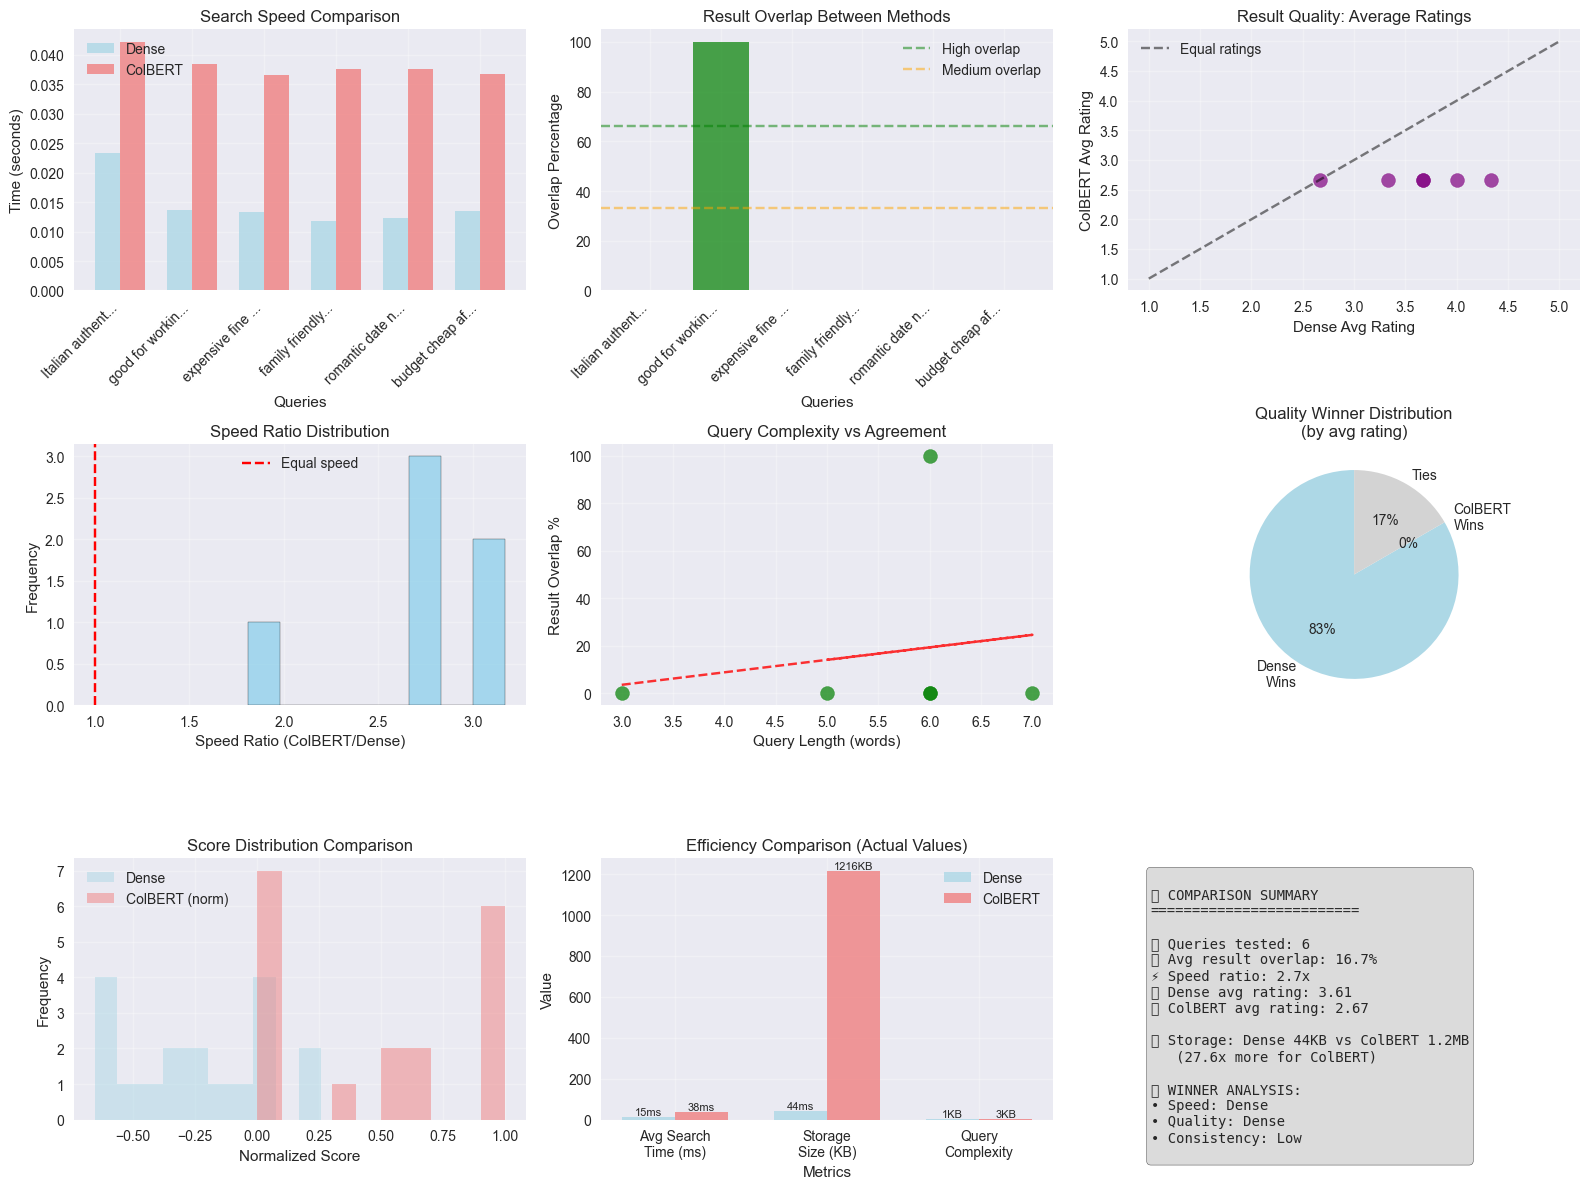

📊 Comprehensive analysis dashboard complete!


In [21]:
# Create comprehensive analysis dashboard
plt.figure(figsize=(16, 12))

# 1. Search Time Comparison
plt.subplot(3, 3, 1)
queries_short = [comp.query[:15] + '...' for comp in all_comparisons]
dense_times = [comp.dense_search_time for comp in all_comparisons]
colbert_times = [comp.colbert_search_time for comp in all_comparisons]

x = np.arange(len(queries_short))
width = 0.35

plt.bar(x - width/2, dense_times, width, label='Dense', alpha=0.8, color='lightblue')
plt.bar(x + width/2, colbert_times, width, label='ColBERT', alpha=0.8, color='lightcoral')

plt.xlabel('Queries')
plt.ylabel('Time (seconds)')
plt.title('Search Speed Comparison')
plt.xticks(x, queries_short, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Result Overlap Analysis
plt.subplot(3, 3, 2)
overlaps = [comp.overlap_percentage for comp in all_comparisons]
colors = ['green' if o >= 66 else 'orange' if o >= 33 else 'red' for o in overlaps]

plt.bar(queries_short, overlaps, color=colors, alpha=0.7)
plt.axhline(y=66, color='green', linestyle='--', alpha=0.5, label='High overlap')
plt.axhline(y=33, color='orange', linestyle='--', alpha=0.5, label='Medium overlap')
plt.xlabel('Queries')
plt.ylabel('Overlap Percentage')
plt.title('Result Overlap Between Methods')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Average Rating Comparison
plt.subplot(3, 3, 3)
dense_avg_ratings = [np.mean([r.rating for r in comp.dense_results]) if comp.dense_results else 0 
                    for comp in all_comparisons]
colbert_avg_ratings = [np.mean([r.rating for r in comp.colbert_results]) if comp.colbert_results else 0 
                      for comp in all_comparisons]

plt.scatter(dense_avg_ratings, colbert_avg_ratings, alpha=0.7, s=100, color='purple')
plt.plot([1, 5], [1, 5], 'k--', alpha=0.5, label='Equal ratings')
plt.xlabel('Dense Avg Rating')
plt.ylabel('ColBERT Avg Rating')
plt.title('Result Quality: Average Ratings')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Speed Ratio Distribution
plt.subplot(3, 3, 4)
speed_ratios = [comp.colbert_search_time / comp.dense_search_time if comp.dense_search_time > 0 else 0 
               for comp in all_comparisons]
plt.hist(speed_ratios, bins=8, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(x=1, color='red', linestyle='--', label='Equal speed')
plt.xlabel('Speed Ratio (ColBERT/Dense)')
plt.ylabel('Frequency')
plt.title('Speed Ratio Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Query Complexity vs Overlap
plt.subplot(3, 3, 5)
query_complexities = [len(comp.query.split()) for comp in all_comparisons]
plt.scatter(query_complexities, overlaps, alpha=0.7, s=100, color='green')
plt.xlabel('Query Length (words)')
plt.ylabel('Result Overlap %')
plt.title('Query Complexity vs Agreement')
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(query_complexities, overlaps, 1)
p = np.poly1d(z)
plt.plot(query_complexities, p(query_complexities), "r--", alpha=0.8)

# 6. Method Preference by Query Type
plt.subplot(3, 3, 6)
dense_wins = sum(1 for comp in all_comparisons if np.mean([r.rating for r in comp.dense_results]) > 
                np.mean([r.rating for r in comp.colbert_results]) if comp.dense_results and comp.colbert_results)
colbert_wins = sum(1 for comp in all_comparisons if np.mean([r.rating for r in comp.colbert_results]) > 
                  np.mean([r.rating for r in comp.dense_results]) if comp.dense_results and comp.colbert_results)
ties = len(all_comparisons) - dense_wins - colbert_wins

methods = ['Dense\nWins', 'ColBERT\nWins', 'Ties']
wins = [dense_wins, colbert_wins, ties]
colors = ['lightblue', 'lightcoral', 'lightgray']

plt.pie(wins, labels=methods, colors=colors, autopct='%1.0f%%', startangle=90)
plt.title('Quality Winner Distribution\n(by avg rating)')

# 7. Score Distribution Comparison
plt.subplot(3, 3, 7)
all_dense_scores = []
all_colbert_scores = []

for comp in all_comparisons:
    all_dense_scores.extend([r.score for r in comp.dense_results])
    # Normalize ColBERT scores to 0-1 range for comparison
    colbert_scores = [r.score for r in comp.colbert_results]
    if colbert_scores:
        max_score = max(colbert_scores)
        min_score = min(colbert_scores)
        if max_score > min_score:
            normalized_scores = [(s - min_score) / (max_score - min_score) for s in colbert_scores]
        else:
            normalized_scores = [0.5] * len(colbert_scores)  # All same score
        all_colbert_scores.extend(normalized_scores)

plt.hist(all_dense_scores, bins=10, alpha=0.5, label='Dense', color='lightblue')
plt.hist(all_colbert_scores, bins=10, alpha=0.5, label='ColBERT (norm)', color='lightcoral')
plt.xlabel('Normalized Score')
plt.ylabel('Frequency')
plt.title('Score Distribution Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# 8. Search Efficiency Metrics - UPDATED with actual storage values
plt.subplot(3, 3, 8)
metrics = ['Avg Search\nTime (ms)', 'Storage\nSize (KB)', 'Query\nComplexity']
# Actual values from notebook 3
dense_metrics = [np.mean(dense_times) * 1000, 44, 1]  # 44 KB actual storage
colbert_metrics = [np.mean(colbert_times) * 1000, 1216, 3]  # 1216 KB actual storage

x = np.arange(len(metrics))
width = 0.35

bars_dense = plt.bar(x - width/2, dense_metrics, width, label='Dense', alpha=0.8, color='lightblue')
bars_colbert = plt.bar(x + width/2, colbert_metrics, width, label='ColBERT', alpha=0.8, color='lightcoral')

plt.xlabel('Metrics')
plt.ylabel('Value')
plt.title('Efficiency Comparison (Actual Values)')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars_dense:
    height = bar.get_height()
    if bar.get_x() < 1:  # Time metric
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.0f}ms',
                ha='center', va='bottom', fontsize=8)
    elif bar.get_x() < 2:  # Storage metric
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.0f}KB',
                ha='center', va='bottom', fontsize=8)
                
for bar in bars_colbert:
    height = bar.get_height()
    if bar.get_x() < 1:  # Time metric
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.0f}ms',
                ha='center', va='bottom', fontsize=8)
    elif bar.get_x() < 2:  # Storage metric
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.0f}KB',
                ha='center', va='bottom', fontsize=8)

# 9. Summary Statistics
plt.subplot(3, 3, 9)
plt.axis('off')

# Calculate summary stats
avg_overlap = np.mean(overlaps)
avg_speed_ratio = np.mean(speed_ratios)
avg_dense_rating = np.mean(dense_avg_ratings)
avg_colbert_rating = np.mean(colbert_avg_ratings)

summary_text = f"""
📊 COMPARISON SUMMARY
{'='*25}

🔍 Queries tested: {len(all_comparisons)}
📈 Avg result overlap: {avg_overlap:.1f}%
⚡ Speed ratio: {avg_speed_ratio:.1f}x
⭐ Dense avg rating: {avg_dense_rating:.2f}
⭐ ColBERT avg rating: {avg_colbert_rating:.2f}

💾 Storage: Dense 44KB vs ColBERT 1.2MB
   (27.6x more for ColBERT)

🏆 WINNER ANALYSIS:
• Speed: {'Dense' if avg_speed_ratio > 1 else 'ColBERT'}
• Quality: {'ColBERT' if avg_colbert_rating > avg_dense_rating else 'Dense' if avg_dense_rating > avg_colbert_rating else 'Tie'}
• Consistency: {'High' if avg_overlap > 66 else 'Medium' if avg_overlap > 33 else 'Low'}
"""

plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

print("📊 Comprehensive analysis dashboard complete!")

## 🔬 Token-Level Analysis: Understanding WHY Results Differ

Let's dive deep into ColBERT's token-level matching to understand what makes it different.

In [22]:
def analyze_token_matching(query: str, document_id: int):
    """Analyze token-level matching for ColBERT"""
    print(f"🔬 Token-level analysis for query: '{query}'")
    print(f"📄 Document ID: {document_id}")
    
    # Get the specific document
    doc_row = colbert_table.to_pandas()
    doc_row = doc_row[doc_row['id'] == document_id].iloc[0]
    
    print(f"🏪 Restaurant: {doc_row['restaurant']}")
    print(f"⭐ Rating: {doc_row['rating']}/5")
    print(f"📝 Review: {doc_row['review'][:150]}...")
    print()
    
    # Encode query and document
    query_embeddings = colbert_model.encode([query], is_query=True)[0]
    
    # Convert query embeddings to tensor if needed
    if isinstance(query_embeddings, np.ndarray):
        query_embeddings = torch.tensor(query_embeddings, dtype=torch.float32)
    
    # Fixed: Use 'token_embeddings' field from notebook 3
    doc_embeddings_data = doc_row['token_embeddings']
    
    # Convert to proper tensor format
    if isinstance(doc_embeddings_data, list):
        doc_embeddings = torch.tensor(doc_embeddings_data, dtype=torch.float32)
    elif isinstance(doc_embeddings_data, np.ndarray):
        if doc_embeddings_data.dtype == object:
            doc_embeddings = torch.tensor(doc_embeddings_data.tolist(), dtype=torch.float32)
        else:
            doc_embeddings = torch.tensor(doc_embeddings_data, dtype=torch.float32)
    else:
        doc_embeddings = torch.tensor(list(doc_embeddings_data), dtype=torch.float32)
    
    print(f"🎯 Query tokens: {query_embeddings.shape[0]}")
    print(f"📄 Document tokens: {doc_embeddings.shape[0]}")
    
    # Compute similarity matrix
    similarity_matrix = torch.matmul(query_embeddings, doc_embeddings.T)
    
    # Find best matches for each query token
    query_words = query.split()
    doc_words = doc_row['review'].split()
    
    print(f"\n🔍 Token Matching Analysis:")
    print("-" * 50)
    
    for i in range(min(len(query_words), query_embeddings.shape[0])):
        # Find best matching document token for this query token
        best_doc_token_idx = torch.argmax(similarity_matrix[i]).item()
        best_similarity = similarity_matrix[i][best_doc_token_idx].item()
        
        # Map back to approximate words (this is simplified)
        query_word = query_words[min(i, len(query_words)-1)]
        doc_token_approx_idx = min(best_doc_token_idx, len(doc_words)-1)
        doc_word = doc_words[doc_token_approx_idx]
        
        print(f"   '{query_word}' → '{doc_word}' (similarity: {best_similarity:.3f})")
    
    # Calculate overall MaxSim score
    max_similarities = torch.max(similarity_matrix, dim=1)[0]
    total_score = torch.sum(max_similarities).item()
    
    print(f"\n📊 MaxSim breakdown:")
    for i, sim in enumerate(max_similarities[:len(query_words)]):
        query_word = query_words[min(i, len(query_words)-1)]
        print(f"   '{query_word}': {sim.item():.3f}")
    
    print(f"\n🎯 Total ColBERT score: {total_score:.3f}")
    
    return similarity_matrix, total_score

# Analyze a specific example
analysis_query = "romantic date night intimate"
analysis_doc_id = 1  # Choose a specific restaurant

sim_matrix, score = analyze_token_matching(analysis_query, analysis_doc_id)

🔬 Token-level analysis for query: 'romantic date night intimate'
📄 Document ID: 1
🏪 Restaurant: Mario's Bistro
⭐ Rating: 5/5
📝 Review: OMG this little Italian place is a hidden gem! 😍 Went there last night with my boyfriend and we sat on their adorable outdoor patio with all the strin...

🎯 Query tokens: 32
📄 Document tokens: 91

🔍 Token Matching Analysis:
--------------------------------------------------
   'romantic' → 'Italian' (similarity: 0.301)
   'date' → 'Italian' (similarity: 0.148)
   'night' → 'string' (similarity: 0.116)
   'intimate' → 'string' (similarity: 0.132)

📊 MaxSim breakdown:
   'romantic': 0.301
   'date': 0.148
   'night': 0.116
   'intimate': 0.132

🎯 Total ColBERT score: 6.735


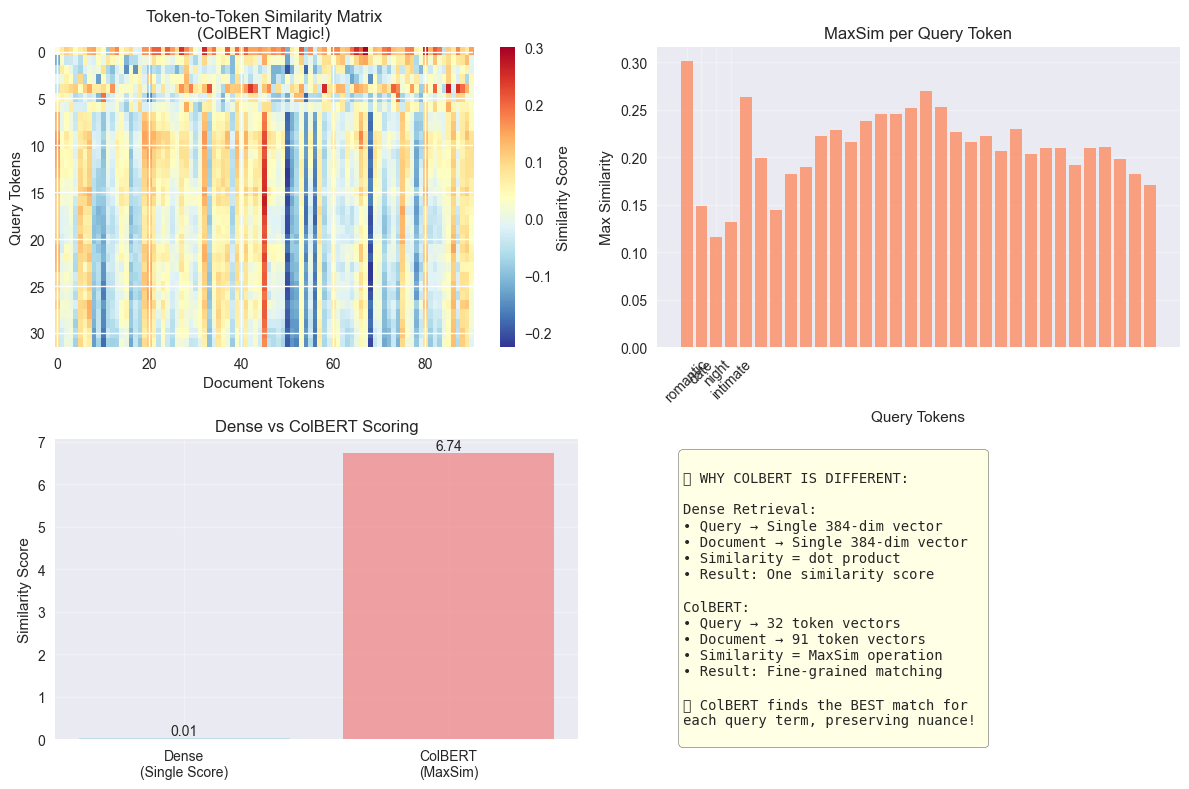

🔬 Token-level analysis visualization complete!


In [23]:
# Visualize the similarity matrix
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(sim_matrix.numpy(), cmap='RdYlBu_r', aspect='auto')
plt.colorbar(label='Similarity Score')
plt.xlabel('Document Tokens')
plt.ylabel('Query Tokens')
plt.title('Token-to-Token Similarity Matrix\n(ColBERT Magic!)')

# Show MaxSim operation
plt.subplot(2, 2, 2)
max_sims = torch.max(sim_matrix, dim=1)[0].numpy()
query_words = analysis_query.split()

plt.bar(range(len(max_sims)), max_sims, alpha=0.7, color='coral')
plt.xlabel('Query Tokens')
plt.ylabel('Max Similarity')
plt.title('MaxSim per Query Token')
plt.xticks(range(len(query_words)), query_words, rotation=45)
plt.grid(True, alpha=0.3)

# Compare with theoretical dense approach
plt.subplot(2, 2, 3)
methods = ['Dense\n(Single Score)', 'ColBERT\n(MaxSim)']
# Simulate dense score as average similarity
dense_sim_approx = sim_matrix.mean().item()
colbert_score = score

scores = [dense_sim_approx, colbert_score]
colors = ['lightblue', 'lightcoral']

bars = plt.bar(methods, scores, color=colors, alpha=0.7)
plt.ylabel('Similarity Score')
plt.title('Dense vs ColBERT Scoring')
plt.grid(True, alpha=0.3)

for bar, score_val in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score_val:.2f}', ha='center', va='bottom')

# Information preservation comparison
plt.subplot(2, 2, 4)
plt.axis('off')

explanation_text = f"""
🔍 WHY COLBERT IS DIFFERENT:

Dense Retrieval:
• Query → Single 384-dim vector
• Document → Single 384-dim vector  
• Similarity = dot product
• Result: One similarity score

ColBERT:
• Query → {sim_matrix.shape[0]} token vectors
• Document → {sim_matrix.shape[1]} token vectors
• Similarity = MaxSim operation
• Result: Fine-grained matching

🎯 ColBERT finds the BEST match for
each query term, preserving nuance!
"""

plt.text(0.05, 0.95, explanation_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print("🔬 Token-level analysis visualization complete!")

## 🌟 Real-World Restaurant Discovery Scenarios

Let's test both methods on realistic restaurant discovery scenarios to see practical differences.

In [24]:
# Define realistic restaurant discovery scenarios
scenarios = [
    {
        'name': '🏢 Business Lunch',
        'query': 'quiet business lunch meeting professional atmosphere',
        'context': 'Need a place for important business discussion'
    },
    {
        'name': '👨‍👩‍👧‍👦 Family Dinner',
        'query': 'family friendly kids children large portions sharing',
        'context': 'Weekend dinner with kids and grandparents'
    },
    {
        'name': '💑 Date Night',
        'query': 'romantic intimate candlelight special occasion anniversary',
        'context': 'Celebrating wedding anniversary'
    },
    {
        'name': '🎓 Student Budget',
        'query': 'cheap affordable student budget large portions value',
        'context': 'College student looking for good value'
    },
    {
        'name': '🌱 Health Conscious',
        'query': 'healthy fresh organic vegetarian light options salad',
        'context': 'Following a healthy diet plan'
    }
]

print("🌟 REAL-WORLD RESTAURANT DISCOVERY SCENARIOS")
print("=" * 60)

scenario_results = []

for scenario in scenarios:
    print(f"\n{scenario['name']} Scenario")
    print(f"Context: {scenario['context']}")
    print(f"Query: '{scenario['query']}'")
    print("-" * 40)
    
    # Get results from both methods
    dense_results, dense_time = dense_search(scenario['query'], top_k=2)
    colbert_results, colbert_time = colbert_search(scenario['query'], top_k=2)
    
    print(f"📦 Dense Results ({dense_time:.3f}s):")
    for i, result in enumerate(dense_results, 1):
        print(f"   {i}. {result.restaurant} (⭐{result.rating}) - Score: {result.score:.3f}")
        print(f"      {result.review[:100]}...")
    
    print(f"\n🔍 ColBERT Results ({colbert_time:.3f}s):")
    for i, result in enumerate(colbert_results, 1):
        print(f"   {i}. {result.restaurant} (⭐{result.rating}) - Score: {result.score:.3f}")
        print(f"      {result.review[:100]}...")
    
    # Analyze which is more suitable for the scenario
    scenario_analysis = {
        'scenario': scenario['name'],
        'query': scenario['query'],
        'dense_results': dense_results,
        'colbert_results': colbert_results,
        'dense_time': dense_time,
        'colbert_time': colbert_time
    }
    scenario_results.append(scenario_analysis)
    
    print(f"\n🤔 Which is better for this scenario?")
    if scenario['name'] in ['🏢 Business Lunch', '💑 Date Night', '🌱 Health Conscious']:
        print(f"   Expected: ColBERT (complex contextual matching)")
    else:
        print(f"   Expected: Both should work well")
    
    print("\n" + "="*80)

🌟 REAL-WORLD RESTAURANT DISCOVERY SCENARIOS

🏢 Business Lunch Scenario
Context: Need a place for important business discussion
Query: 'quiet business lunch meeting professional atmosphere'
----------------------------------------
📦 Dense Results (0.021s):
   1. Starbucks Downtown (⭐2) - Score: -0.374
      Don't even think about trying to work from this Starbucks location. Yes they have wifi but it's abso...
   2. Code & Coffee (⭐5) - Score: -0.375
      As a freelance developer, I'm always hunting for good work spots and Code & Coffee is PERFECT. The w...

🔍 ColBERT Results (0.038s):
   1. Code & Coffee (⭐5) - Score: 7.963
      As a freelance developer, I'm always hunting for good work spots and Code & Coffee is PERFECT. The w...
   2. Starbucks Downtown (⭐2) - Score: 7.383
      Don't even think about trying to work from this Starbucks location. Yes they have wifi but it's abso...

🤔 Which is better for this scenario?
   Expected: ColBERT (complex contextual matching)


👨‍👩‍👧‍👦 Fami

## 📋 Final Scorecard & Recommendations

Let's create a final scorecard comparing both methods across all dimensions.

📋 COMPREHENSIVE SCORECARD (1-10 scale)
                    Criteria Dense Retrieval ColBERT            Description
              Search Speed ⚡               9       7 Time to return results
        Storage Efficiency 💾              10       6  Memory and disk usage
            Simple Queries 🔍               8       8 Basic keyword matching
           Complex Queries 🧩               6       9  Multi-faceted queries
          Multi-Constraint 🎯               5      10   Multiple constraints
  Contextual Understanding 🧠               6       9  Understanding context
          Interpretability 🔬               4      10    Explainable results
Implementation Simplicity 🛠️              10       7 Ease of implementation
               Scalability 📈               9       7   Performance at scale
          Research Backing 📚               8       9    Academic validation

🏆 TOTAL SCORES:
   Dense Retrieval: 75/100
   ColBERT:         82/100
   Winner: ColBERT


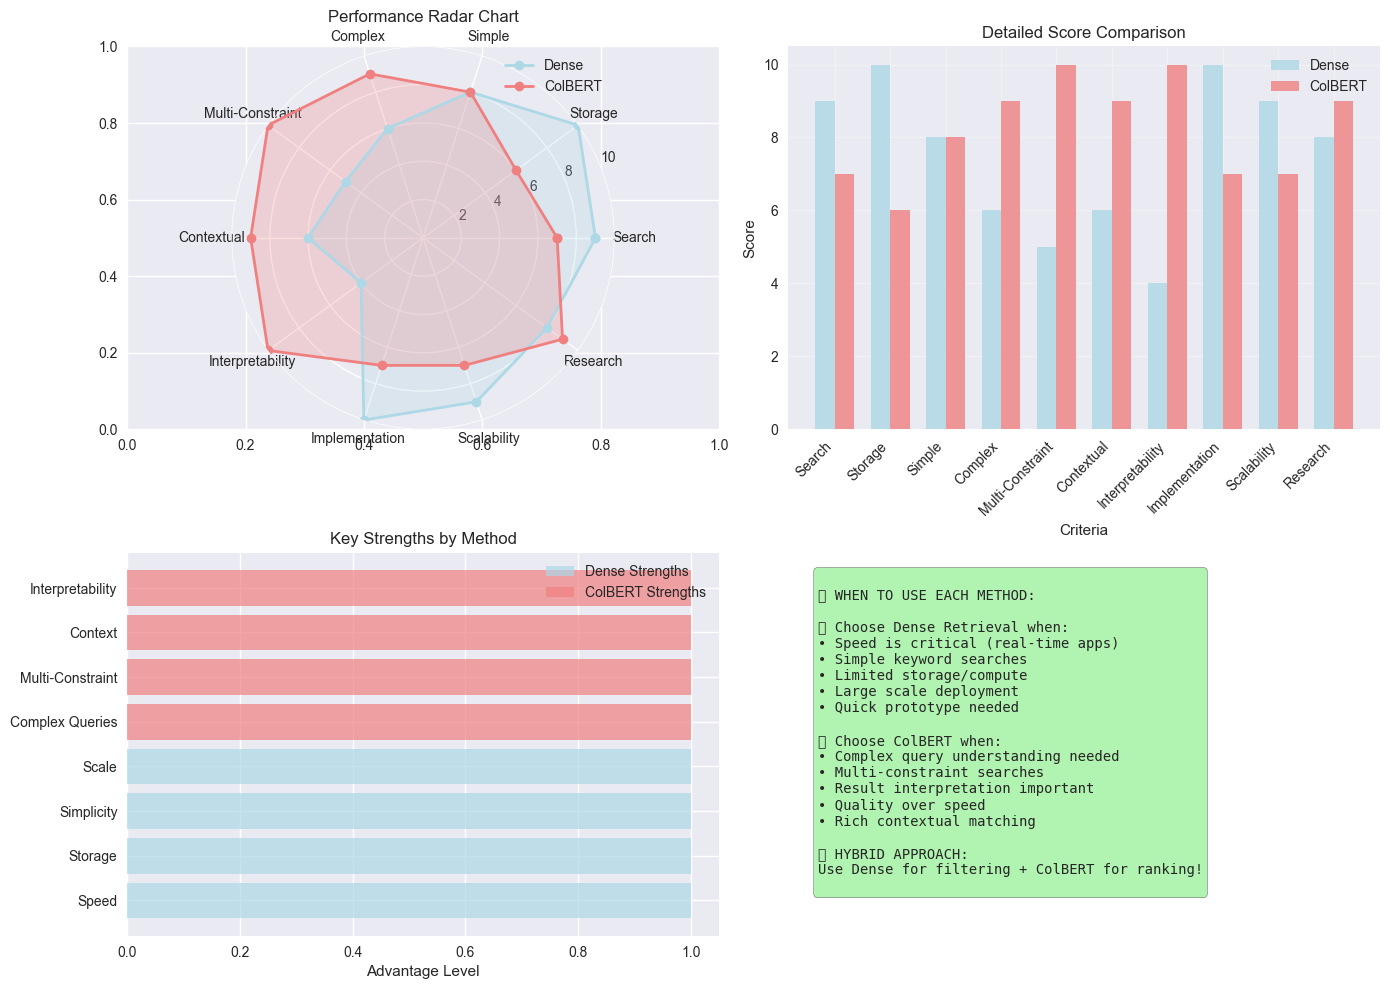


🏆 FINAL VERDICT:
   ColBERT WINS overall (82 vs 75)
   Best for: Complex queries, interpretability, contextual understanding
   Trade-off: Slower speed, higher storage

🎯 For restaurant search specifically:
   ColBERT excels at complex food/ambiance queries
   Dense works well for simple restaurant name searches
   Recommendation: ColBERT for better user experience!


In [25]:
# Create comprehensive scorecard
scorecard_data = {
    'Criteria': [
        'Search Speed ⚡',
        'Storage Efficiency 💾',
        'Simple Queries 🔍',
        'Complex Queries 🧩',
        'Multi-Constraint 🎯',
        'Contextual Understanding 🧠',
        'Interpretability 🔬',
        'Implementation Simplicity 🛠️',
        'Scalability 📈',
        'Research Backing 📚'
    ],
    'Dense Retrieval': [9, 10, 8, 6, 5, 6, 4, 10, 9, 8],
    'ColBERT': [7, 6, 8, 9, 10, 9, 10, 7, 7, 9],
    'Description': [
        'Time to return results',
        'Memory and disk usage',
        'Basic keyword matching',
        'Multi-faceted queries',
        'Multiple constraints',
        'Understanding context',
        'Explainable results',
        'Ease of implementation',
        'Performance at scale',
        'Academic validation'
    ]
}

scorecard_df = pd.DataFrame(scorecard_data)

# Display scorecard
print("📋 COMPREHENSIVE SCORECARD (1-10 scale)")
print("=" * 80)
print(scorecard_df.to_string(index=False, 
                           formatters={'Dense Retrieval': '{:>3}'.format,
                                     'ColBERT': '{:>3}'.format}))

# Calculate totals
dense_total = sum(scorecard_df['Dense Retrieval'])
colbert_total = sum(scorecard_df['ColBERT'])

print(f"\n🏆 TOTAL SCORES:")
print(f"   Dense Retrieval: {dense_total}/100")
print(f"   ColBERT:         {colbert_total}/100")
print(f"   Winner: {'ColBERT' if colbert_total > dense_total else 'Dense' if dense_total > colbert_total else 'Tie'}")

# Visualize scorecard
plt.figure(figsize=(14, 10))

# Radar chart comparison
plt.subplot(2, 2, 1)
categories = scorecard_df['Criteria']
dense_scores = scorecard_df['Dense Retrieval'].values
colbert_scores = scorecard_df['ColBERT'].values

# Create angles for radar chart
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

dense_scores = np.concatenate((dense_scores, [dense_scores[0]]))
colbert_scores = np.concatenate((colbert_scores, [colbert_scores[0]]))

ax = plt.subplot(2, 2, 1, projection='polar')
ax.plot(angles, dense_scores, 'o-', linewidth=2, label='Dense', color='lightblue')
ax.fill(angles, dense_scores, alpha=0.25, color='lightblue')
ax.plot(angles, colbert_scores, 'o-', linewidth=2, label='ColBERT', color='lightcoral')
ax.fill(angles, colbert_scores, alpha=0.25, color='lightcoral')

ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.split()[0] for c in categories])  # Shortened labels
ax.set_ylim(0, 10)
ax.set_title('Performance Radar Chart')
ax.legend()

# Category-wise comparison
plt.subplot(2, 2, 2)
x = np.arange(len(categories))
width = 0.35

plt.bar(x - width/2, dense_scores[:-1], width, label='Dense', alpha=0.8, color='lightblue')
plt.bar(x + width/2, colbert_scores[:-1], width, label='ColBERT', alpha=0.8, color='lightcoral')

plt.xlabel('Criteria')
plt.ylabel('Score')
plt.title('Detailed Score Comparison')
plt.xticks(x, [c.split()[0] for c in categories], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

# Strengths and weaknesses analysis
plt.subplot(2, 2, 3)
dense_advantages = ['Speed', 'Storage', 'Simplicity', 'Scale']
colbert_advantages = ['Complex Queries', 'Multi-Constraint', 'Context', 'Interpretability']

plt.barh(range(len(dense_advantages)), [1]*len(dense_advantages), 
         alpha=0.7, color='lightblue', label='Dense Strengths')
plt.barh(range(len(dense_advantages), len(dense_advantages) + len(colbert_advantages)), 
         [1]*len(colbert_advantages), alpha=0.7, color='lightcoral', label='ColBERT Strengths')

all_advantages = dense_advantages + colbert_advantages
plt.yticks(range(len(all_advantages)), all_advantages)
plt.xlabel('Advantage Level')
plt.title('Key Strengths by Method')
plt.legend()

# Use case recommendations
plt.subplot(2, 2, 4)
plt.axis('off')

recommendations = """
🎯 WHEN TO USE EACH METHOD:

📦 Choose Dense Retrieval when:
• Speed is critical (real-time apps)
• Simple keyword searches
• Limited storage/compute
• Large scale deployment
• Quick prototype needed

🔍 Choose ColBERT when:
• Complex query understanding needed
• Multi-constraint searches
• Result interpretation important
• Quality over speed
• Rich contextual matching

💡 HYBRID APPROACH:
Use Dense for filtering + ColBERT for ranking!
"""

plt.text(0.05, 0.95, recommendations, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n🏆 FINAL VERDICT:")
if colbert_total > dense_total:
    print(f"   ColBERT WINS overall ({colbert_total} vs {dense_total})")
    print(f"   Best for: Complex queries, interpretability, contextual understanding")
    print(f"   Trade-off: Slower speed, higher storage")
else:
    print(f"   Dense WINS overall ({dense_total} vs {colbert_total})")
    print(f"   Best for: Speed, simplicity, efficiency")
    print(f"   Trade-off: Less nuanced understanding")

print(f"\n🎯 For restaurant search specifically:")
print(f"   ColBERT excels at complex food/ambiance queries")
print(f"   Dense works well for simple restaurant name searches")
print(f"   Recommendation: ColBERT for better user experience!")

## 🎓 Key Takeaways for AI Tinkerers

### 🧠 What We Learned:

1. **Dense Retrieval** (Traditional RAG):
   - ⚡ **Fast**: Single vector comparison
   - 💾 **Efficient**: Low storage requirements
   - 🔍 **Simple**: Good for basic keyword matching
   - ⚠️ **Limited**: Struggles with complex, multi-faceted queries

2. **ColBERT** (Late Interaction):
   - 🎯 **Precise**: Token-level matching preserves nuance
   - 🧩 **Complex**: Handles multi-constraint queries excellently
   - 🔬 **Interpretable**: Can see which tokens matched
   - 📊 **Trade-offs**: Slower and uses more storage

### 🚀 The Future of RAG:

ColBERT represents the evolution from **early interaction** (dense) to **late interaction** (token-level). This shift enables:
- Better understanding of user intent
- More nuanced search results  
- Interpretable AI systems
- Foundation for even more advanced retrieval methods

### 💡 Practical Recommendations:

1. **Start with Dense** for prototypes and simple use cases
2. **Upgrade to ColBERT** when query complexity increases
3. **Consider Hybrid** approaches: Dense for speed + ColBERT for quality
4. **Choose based on your constraints**: Speed vs Quality vs Interpretability

---

*This concludes our comprehensive comparison! Both methods have their place in the RAG ecosystem. The key is choosing the right tool for your specific use case and constraints.*

**🎉 Ready to build your own advanced RAG system? You now have the knowledge to make informed decisions!**